# Regresion Logistica

## Entender el Dataset

El data set `KDD Cup 1999` contiene conexiones de red de un entorno militar simulado. Cada fila es una conexion y el objetivo es predecir si la `normal(0)` o `ataque(1)`.

| duration | protocol_type | service | src_bytes | dst_bytes | flag | label   |
| -------- | ------------- | ------- | --------- | --------- | ---- | ------- |
| 0        | tcp           | http    | 215       | 45076     | SF   | normal  |
| 0        | udp           | private | 105       | 0         | SF   | neptune |
| 2        | tcp           | ftp     | 1228      | 0         | RSTO | ipsweep |

**La mision**: que el modelo aprenda a predecir si `label = 'normal'` o `label = cualquier ataque`.

In [13]:
# Cargar y Explorar

import pandas as pd
import numpy as np

columnas = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_hot_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

df = pd.read_csv(
    '../Datasets/2_kddcup/kddcup.data_10_percent',
    names=columnas
)

In [14]:
print("Filas y Columnas:", df.shape)
print("\nPrimeras 3 filas:")
display(df.head(3))
print("\nDistribución de labels:")
print(df['label'].value_counts().head(8))


Filas y Columnas: (494021, 42)

Primeras 3 filas:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.



Distribución de labels:
label
smurf.          280790
neptune.        107201
normal.          97278
back.             2203
satan.            1589
ipsweep.          1247
portsweep.        1040
warezclient.      1020
Name: count, dtype: int64


In [15]:
# normal. → 0  |  cualquier ataque → 1
df['y'] = (df['label'] != 'normal.').astype(int)

print("Distribución de y:")
print(df['y'].value_counts())
print(f"\n% de ataques: {df['y'].mean()*100:.1f}%")
print(f"% de normales: {(1-df['y'].mean())*100:.1f}%")


Distribución de y:
y
1    396743
0     97278
Name: count, dtype: int64

% de ataques: 80.3%
% de normales: 19.7%


In [16]:
# Definir columnas

numericas = [
    "duration", "src_bytes", "dst_bytes", "land", "wrong_fragment",
    "urgent", "hot", "num_failed_logins", "logged_in", "num_compromised",
    "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds",
    "is_hot_login", "is_guest_login", "count", "srv_count",
    "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate"
]

categoricas = ["protocol_type", "service", "flag"]
target      = "y"

df_modelo = df[numericas + categoricas + [target]].copy()
print("Columnas seleccionadas:", df_modelo.shape[1])
print("Conexiones:", df_modelo.shape[0])


Columnas seleccionadas: 42
Conexiones: 494021


In [17]:
# Limpiar NaN

print("NaN por columna:\n", df_modelo.isnull().sum())
print(f"\nTotal filas ANTES: {len(df_modelo)}")
df_modelo = df_modelo.dropna()
print(f"Total filas DESPUÉS: {len(df_modelo)}")


NaN por columna:
 duration                       0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_hot_login                   0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_host_rate             0
dst_host_count                 0
dst_host_srv_count       

In [18]:
# One-Hot encoding

df_modelo = pd.get_dummies(
    df_modelo,
    columns=categoricas,
    drop_first=True
)

print("Columnas después del encoding:", df_modelo.shape[1])
print(df_modelo.columns.tolist())


Columnas después del encoding: 116
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_hot_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'y', 'protocol_type_tcp', 'protocol_type_udp', 'service_X11', 'service_Z39_50', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'service_domain_u', 'service_echo', 'service_eco_i',

In [19]:
# separamos en X e y
y = df_modelo[target].values.astype(float)
X = df_modelo.drop(columns=[target]).values.astype(float)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("dtype X:", X.dtype)


Forma de X: (494021, 115)
Forma de y: (494021,)
dtype X: float64


In [20]:
 # Normalizamos

n_numericas = len(numericas)   # 38

mu    = np.zeros(X.shape[1])
sigma = np.ones(X.shape[1])

mu[:n_numericas]    = X[:, :n_numericas].mean(axis=0)
sigma[:n_numericas] = X[:, :n_numericas].std(axis=0)

sigma[sigma == 0] = 1   # ← evitar división por cero

X_norm = (X - mu) / sigma

print("mu shape:",    mu.shape)
print("sigma shape:", sigma.shape)
print("X_norm shape:", X_norm.shape)
print("Media (primeras 5):", X_norm[:, :5].mean(axis=0).round(2))
print("Std   (primeras 5):", X_norm[:, :5].std(axis=0).round(2))


mu shape: (115,)
sigma shape: (115,)
X_norm shape: (494021, 115)
Media (primeras 5): [ 0.  0.  0. -0. -0.]
Std   (primeras 5): [1. 1. 1. 1. 1.]


In [21]:
# Agregar x_0 = 1 y dividir Train/test

from sklearn.model_selection import train_test_split

m   = X_norm.shape[0]
X_b = np.c_[np.ones((m, 1)), X_norm]

print("X_b shape:", X_b.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_b, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ← mantiene proporción de ataques en cada set
)

print("Conexiones de entrenamiento:", X_train.shape[0])
print("Conexiones de prueba:",        X_test.shape[0])
print("Features (con x₀=1):",         X_train.shape[1])


X_b shape: (494021, 116)
Conexiones de entrenamiento: 395216
Conexiones de prueba: 98805
Features (con x₀=1): 116


## Funciones

In [22]:
#funcion sigmoide

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

print("Sigmoid(0):", sigmoid(0))
print("Sigmoid(10):", sigmoid(10))

Sigmoid(0): 0.5
Sigmoid(10): 0.9999546021312976


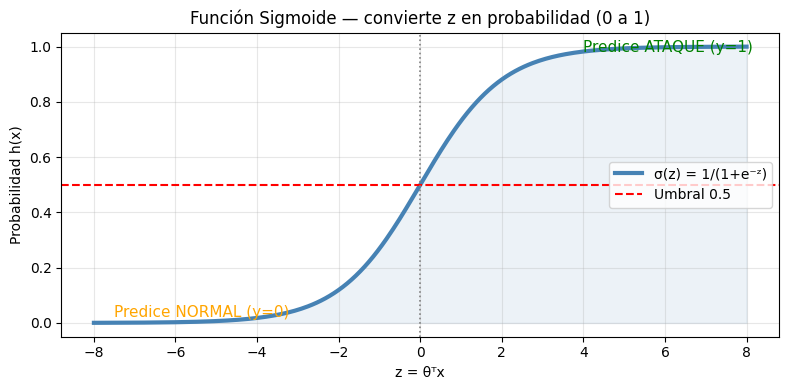

In [35]:
import matplotlib.pyplot as plt

z = np.linspace(-8, 8, 300)

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid(z), color='steelblue', linewidth=3, label='σ(z) = 1/(1+e⁻ᶻ)')
plt.axhline(0.5,  color='red',  linestyle='--', linewidth=1.5, label='Umbral 0.5')
plt.axvline(0,    color='gray', linestyle=':',  linewidth=1.2)
plt.fill_between(z, sigmoid(z), alpha=0.1, color='steelblue')

plt.annotate('Predice ATAQUE (y=1)',  xy=(4,  0.98), fontsize=11, color='green')
plt.annotate('Predice NORMAL (y=0)', xy=(-7.5, 0.02), fontsize=11, color='orange')

plt.xlabel("z = θᵀx")
plt.ylabel("Probabilidad h(x)")
plt.title("Función Sigmoide — convierte z en probabilidad (0 a 1)")
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Funcion Hipotesis

def hipotesis(X, theta):
    return sigmoid(X.dot(theta))
    
theta_test = np.zeros(X_train.shape[1])
preds = hipotesis(X_train, theta_test)
print("Primeras 5 predicciones:", preds[:5].round(4))

Primeras 5 predicciones: [0.5 0.5 0.5 0.5 0.5]


In [25]:
# Funcion de costo (log loss)

def costo(X_b, y, theta):
    m = len(y)
    h = hipotesis(X_b, theta)
    h = np.clip(h, 1e-10, 1 - 1e-10)   # evitar log(0)
    j = -(1/m) * (y.dot(np.log(h)) + (1 - y).dot(np.log(1 - h)))
    return j

theta = np.zeros(X_train.shape[1])
j_inicial = costo(X_train, y_train, theta)
print(f"Costo inicial J(θ=0): {j_inicial:.4f}")


Costo inicial J(θ=0): 0.6931


In [26]:
# Descenso del gradiente

def gradient_descent(X_b, y, theta, alpha=0.01, num_iters=1000):
    m = len(y)
    j_historia = []

    for i in range(num_iters):
        predicciones = hipotesis(X_b, theta)
        errores = predicciones - y
        gradiente = (1/m) * X_b.T.dot(errores)
        theta = theta - alpha * gradiente
        j_historia.append(costo(X_b, y, theta))

        if i % 100 == 0:
            print(f"iter {i:4d} J= {j_historia[-1]:.4f}", flush=True)
    return theta, j_historia

## Entrenar

In [27]:
# Entrenar

theta_inicial = np.zeros(X_train.shape[1])

theta_final, j_historia = gradient_descent(
    X_train, y_train,
    theta_inicial,
    alpha=0.1,
    num_iters=1000
)

print("\nEntrenamiento completo")
print(f"Costo inicial : {j_historia[0]:.6f}")
print(f"Costo final   : {j_historia[-1]:.6f}")


iter    0 J= 0.6303
iter  100 J= 0.0844
iter  200 J= 0.0610
iter  300 J= 0.0520
iter  400 J= 0.0467
iter  500 J= 0.0431
iter  600 J= 0.0403
iter  700 J= 0.0380
iter  800 J= 0.0362
iter  900 J= 0.0346

Entrenamiento completo
Costo inicial : 0.630279
Costo final   : 0.033273


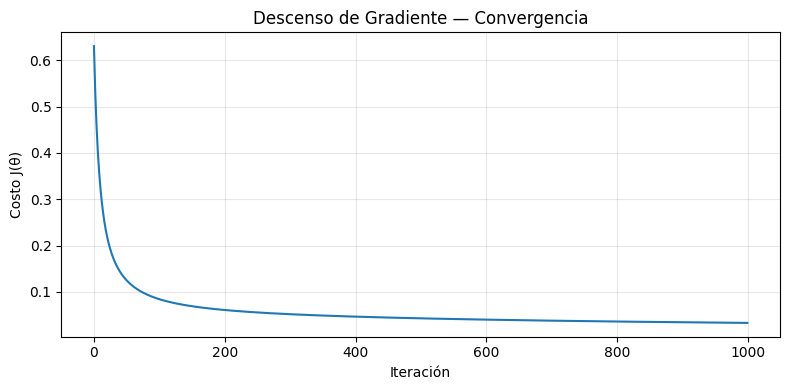

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(j_historia)
plt.xlabel("Iteración")
plt.ylabel("Costo J(θ)")
plt.title("Descenso de Gradiente — Convergencia")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [31]:
# Prueba con una conexión nueva inventada

# Simulamos una conexión sospechosa: duración alta, muchos bytes de origen, sin login
conexion_nueva = np.zeros(len(numericas) + len(df_modelo.columns) - len(numericas) - 1)

# Llenar solo las numéricas que importan
nombres_features = df_modelo.drop(columns=[target]).columns.tolist()

nueva = pd.DataFrame([{col: 0 for col in nombres_features}])
nueva["duration"]         = 300     # conexión larga
nueva["src_bytes"]        = 50000   # muchos bytes enviados
nueva["dst_bytes"]        = 0       # sin respuesta
nueva["num_failed_logins"]= 5       # 5 intentos fallidos
nueva["logged_in"]        = 0       # no logueado
nueva["count"]            = 500     # muchas conexiones al mismo host
nueva["serror_rate"]      = 1.0     # 100% errores SYN
nueva["srv_serror_rate"]  = 1.0

# Normalizar con los mismos mu y sigma del entrenamiento
x_nueva = nueva.values.astype(float).flatten()
x_nueva_norm = (x_nueva - mu) / sigma
x_nueva_b = np.r_[1, x_nueva_norm]  # agregar x_0 = 1

# Predecir
prob = hipotesis(x_nueva_b, theta_final)
pred = "ATAQUE" if prob >= 0.5 else "NORMAL"

print("═" * 50)
print("  PRUEBA: Conexión sospechosa inventada")
print("═" * 50)
print(f"  Duración: 300s | src_bytes: 50000 | failed_logins: 5")
print(f"  serror_rate: 1.0 | logged_in: No")
print(f"")
print(f"  Probabilidad de ataque: {prob:.4f} ({prob*100:.1f}%)")
print(f"  Predicción: {pred}")
print("═" * 50)

# También probamos con una conexión que parece normal ----------------------------------------------
nueva2 = pd.DataFrame([{col: 0 for col in nombres_features}])
nueva2["duration"]        = 0
nueva2["src_bytes"]       = 200
nueva2["dst_bytes"]       = 45000    # respuesta grande (página web)
nueva2["logged_in"]       = 1        # sí logueado
nueva2["count"]           = 2
nueva2["same_srv_rate"]   = 1.0      # siempre mismo servicio
nueva2["dst_host_same_srv_rate"] = 1.0

x_nueva2 = nueva2.values.astype(float).flatten()
x_nueva2_norm = (x_nueva2 - mu) / sigma
x_nueva2_b = np.r_[1, x_nueva2_norm]

prob2 = hipotesis(x_nueva2_b, theta_final)
pred2 = "ATAQUE" if prob2 >= 0.5 else "NORMAL"

print(f"\n  PRUEBA: Conexión normal inventada")
print("═" * 50)
print(f"  Duración: 0s | src_bytes: 200 | dst_bytes: 45000")
print(f"  logged_in: Sí | same_srv_rate: 1.0")
print(f"")
print(f"  Probabilidad de ataque: {prob2:.4f} ({prob2*100:.1f}%)")
print(f"  Predicción: {pred2}")
print("═" * 50)

══════════════════════════════════════════════════
  PRUEBA: Conexión sospechosa inventada
══════════════════════════════════════════════════
  Duración: 300s | src_bytes: 50000 | failed_logins: 5
  serror_rate: 1.0 | logged_in: No

  Probabilidad de ataque: 1.0000 (100.0%)
  Predicción: ATAQUE
══════════════════════════════════════════════════

  PRUEBA: Conexión normal inventada
══════════════════════════════════════════════════
  Duración: 0s | src_bytes: 200 | dst_bytes: 45000
  logged_in: Sí | same_srv_rate: 1.0

  Probabilidad de ataque: 0.0015 (0.1%)
  Predicción: NORMAL
══════════════════════════════════════════════════
